# Wajjahni · Saudi Tourism Analysis (2015–2024)

Exploring official tourism statistics for Saudi Arabia: trends over time, domestic vs inbound tourism, regions, spending, length of stay, and growth.

**Data:** `data/clean/tourism_by_region.csv` (cleaned in `data-cleaning.ipynb`)

In [16]:
import pandas as pd

df = pd.read_csv("data/clean/tourism_by_region.csv")
df.head()

,region,year,tourism_type,tourists_thousands,overnight_stays_thousands,spending_sar_millions,avg_stay_nights,avg_spending_per_trip_sar,avg_spending_per_night_sar
0,Al-Baha,2015,Domestic,1041.0,8807.0,1120.0,8.5,1075.0,127.0
1,Al-Baha,2016,Domestic,1223.0,9707.0,1350.0,7.9,1104.0,139.0
2,Al-Baha,2017,Domestic,1106.0,7126.0,1028.0,6.4,929.0,144.0
3,Al-Baha,2018,Domestic,1235.0,8864.0,1380.0,7.2,1118.0,156.0
4,Al-Baha,2019,Domestic,1462.0,11016.0,1666.0,7.5,1140.0,151.0


In [17]:
df.shape

(259, 9)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   region                      259 non-null    str    
 1   year                        259 non-null    int64  
 2   tourism_type                259 non-null    str    
 3   tourists_thousands          258 non-null    float64
 4   overnight_stays_thousands   259 non-null    float64
 5   spending_sar_millions       259 non-null    float64
 6   avg_stay_nights             259 non-null    float64
 7   avg_spending_per_trip_sar   259 non-null    float64
 8   avg_spending_per_night_sar  259 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 22.2 KB


In [19]:
df.describe()

,year,tourists_thousands,overnight_stays_thousands,spending_sar_millions,avg_stay_nights,avg_spending_per_trip_sar,avg_spending_per_night_sar
count,259.000000,258.000000,259.000000,259.000000,259.000000,259.000000,259.000000
mean,2019.509653,2886.189922,20981.980695,6390.522780,9.353668,2650.876448,361.671815
std,2.879173,4627.815202,44089.971804,15767.346323,9.108162,2037.427885,285.426358
min,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,92.250000,656.000000,251.500000,4.850000,1191.000000,184.000000
50%,2020.000000,994.000000,6315.000000,1237.000000,6.500000,1801.000000,247.000000
75%,2022.000000,3830.250000,22093.000000,5672.000000,9.100000,3682.000000,441.000000
max,2024.000000,23487.000000,430796.000000,140770.000000,59.400000,12319.000000,1685.000000


In [20]:
df.sort_values("tourists_thousands", ascending=False).head()

,region,year,tourism_type,tourists_thousands,overnight_stays_thousands,spending_sar_millions,avg_stay_nights,avg_spending_per_trip_sar,avg_spending_per_night_sar
169,Makkah,2024,Domestic,23487.0,130615.0,30657.0,5.6,1305.0,235.0
167,Makkah,2022,Domestic,22663.0,99556.0,30647.0,4.4,1352.0,308.0
168,Makkah,2023,Domestic,22625.0,113134.0,29941.0,5.0,1323.0,265.0
179,Makkah,2024,Inbound,19570.0,430796.0,140770.0,22.0,7193.0,327.0
166,Makkah,2021,Domestic,18476.0,85256.0,31003.0,4.6,1678.0,364.0


In [24]:
df[df["tourists_thousands"]==0]

,region,year,tourism_type,tourists_thousands,overnight_stays_thousands,spending_sar_millions,avg_stay_nights,avg_spending_per_trip_sar,avg_spending_per_night_sar
12,Al-Baha,2017,Inbound,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
import numpy as np

In [26]:
import numpy as np

numeric_cols = [
    "tourists_thousands",
    "overnight_stays_thousands",
    "spending_sar_millions",
    "avg_stay_nights",
    "avg_spending_per_trip_sar",
    "avg_spending_per_night_sar",
]

df.loc[df["tourists_thousands"] == 0, numeric_cols] = np.nan

In [27]:
df[df["tourists_thousands"] == 0]

,region,year,tourism_type,tourists_thousands,overnight_stays_thousands,spending_sar_millions,avg_stay_nights,avg_spending_per_trip_sar,avg_spending_per_night_sar


In [28]:
df.loc[12]

region                        Al-Baha
year                             2017
tourism_type                  Inbound
tourists_thousands                NaN
overnight_stays_thousands         NaN
spending_sar_millions             NaN
avg_stay_nights                   NaN
avg_spending_per_trip_sar         NaN
avg_spending_per_night_sar        NaN
Name: 12, dtype: object

I found one row (Al-Baha, 2017, Inbound) where every value was 0, including the averages. That's not possible if there were really no tourists, so it's most likely missing data. I replaced these zeros with NaN so they don't pull the averages down.

In [29]:
df[(df["year"] == 2024) & (df["tourism_type"] == "Domestic")]

,region,year,tourism_type,tourists_thousands,overnight_stays_thousands,spending_sar_millions,avg_stay_nights,avg_spending_per_trip_sar,avg_spending_per_night_sar
9,Al-Baha,2024,Domestic,1127.0,10346.0,1123.0,9.2,997.0,109.0
29,Al-Jouf,2024,Domestic,1159.0,9587.0,1571.0,8.3,1355.0,164.0
49,Al-Qassim,2024,Domestic,4872.0,31343.0,5690.0,6.4,1168.0,182.0
69,Aseer,2024,Domestic,7334.0,61211.0,8599.0,8.4,1172.0,140.0
89,Eastern Province,2024,Domestic,13644.0,81591.0,16422.0,6.0,1204.0,201.0
109,Hail,2024,Domestic,1841.0,13792.0,2550.0,7.5,1385.0,185.0
129,Jazan,2024,Domestic,2936.0,16840.0,2858.0,5.7,973.0,170.0
149,Madinah,2024,Domestic,6721.0,34644.0,7475.0,5.2,1112.0,216.0
169,Makkah,2024,Domestic,23487.0,130615.0,30657.0,5.6,1305.0,235.0
189,Najran,2024,Domestic,1259.0,11352.0,2115.0,9.0,1680.0,186.0


In [31]:
df[(df["year"] == 2024) & (df["tourism_type"] == "Domestic")]["tourists_thousands"].sum()

np.float64(86157.0)

In 2024, Saudi Arabia had about 86.2 million domestic tourists (overnight visitors).

In [32]:
df[(df["year"] == 2024) & (df["tourism_type"] == "Inbound")]["tourists_thousands"].sum()

np.float64(29727.0)

In [33]:
df[(df["year"] == 2019) & (df["tourism_type"] == "Domestic")]["tourists_thousands"].sum()

np.float64(47805.0)

In [34]:
df[(df["year"] == 2020) & (df["tourism_type"] == "Domestic")]["tourists_thousands"].sum()

np.float64(42107.0)

In [35]:
(86157 - 47805) / 47805 * 100

80.22591779102605

Domestic tourism grew by 80% between 2019 and 2024

In [36]:
df.groupby("year")["tourists_thousands"].sum()

year
2015     64444.0
2016     63081.0
2017     59928.0
2018     58590.0
2019     65333.0
2020     46248.0
2021     67312.0
2022     94474.0
2023    109343.0
2024    115884.0
Name: tourists_thousands, dtype: float64

### Tourism trend (2015–2024)

- **2015–2019:** Tourism was stable at around **60–65 million** tourists a year.
- **2020:** The lowest year, at **46.2 million**, because of COVID-19 travel restrictions.
- **2021–2024:** Strong growth, from **67.3 million** to **115.9 million**, nearly double the pre-COVID level.

This growth matches the opening of Saudi Arabia to tourism: the tourist e-visa launched in late 2019, plus big events and projects under Vision 2030.

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='year'>

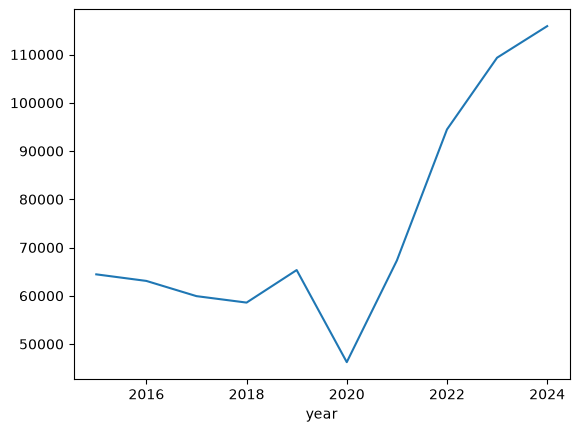

In [37]:
df.groupby("year")["tourists_thousands"].sum().plot()

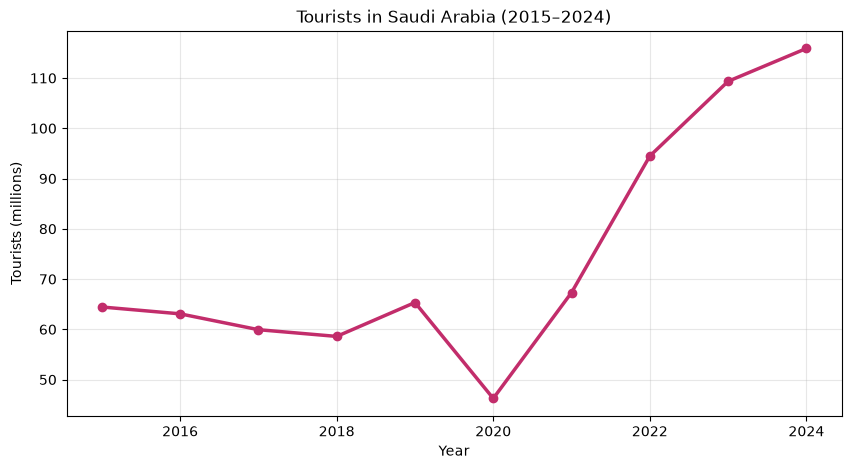

In [38]:
import matplotlib.pyplot as plt

yearly = df.groupby("year")["tourists_thousands"].sum() / 1000

yearly.plot(
    kind="line",
    color="#C22D6B",
    marker="o",
    linewidth=2.5,
    figsize=(10, 5),
    title="Tourists in Saudi Arabia (2015–2024)",
)

plt.xlabel("Year")
plt.ylabel("Tourists (millions)")
plt.grid(alpha=0.3)
plt.show()

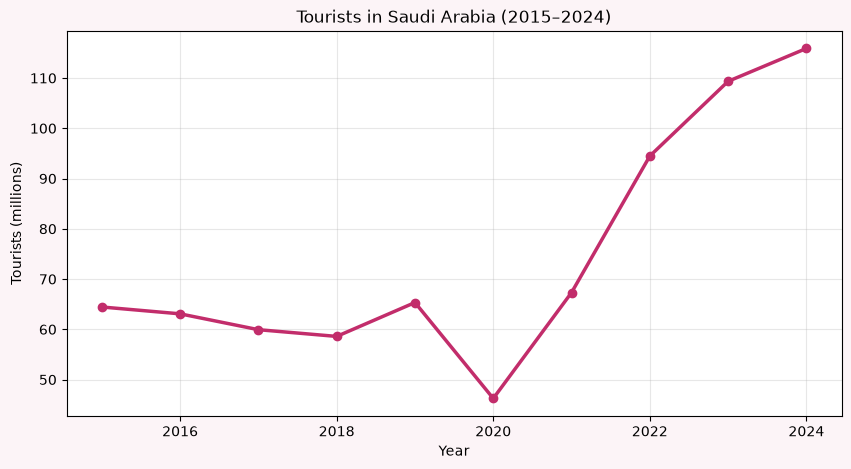

In [39]:
import matplotlib.pyplot as plt

yearly = df.groupby("year")["tourists_thousands"].sum() / 1000

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor("#FCF4F7")   # خلفية الإطار برا
ax.set_facecolor("#FFFFFF")          # خلفية منطقة الرسم داخل

yearly.plot(
    ax=ax,
    color="#C22D6B",
    marker="o",
    linewidth=2.5,
    title="Tourists in Saudi Arabia (2015–2024)",
)

ax.set_xlabel("Year")
ax.set_ylabel("Tourists (millions)")
ax.grid(alpha=0.3)
plt.show()

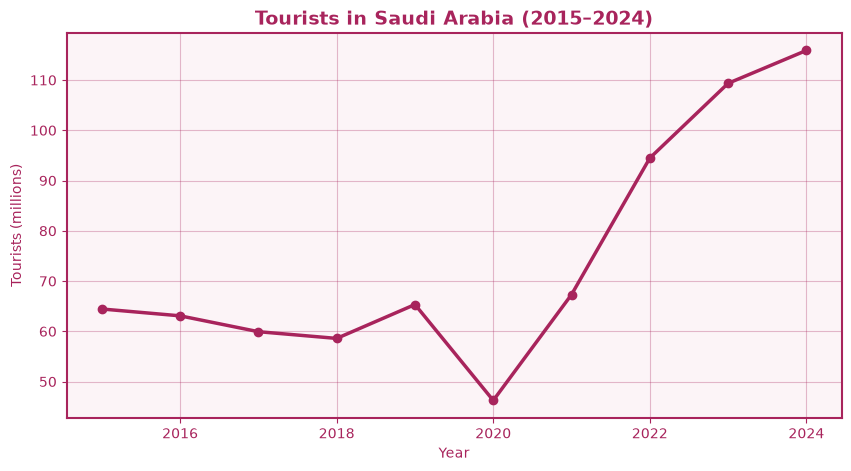

In [42]:
import matplotlib.pyplot as plt

yearly = df.groupby("year")["tourists_thousands"].sum() / 1000

DARK_PINK = "#A8245C"   # الوردي الغامق: الخط والنصوص والإطار
INSIDE = "#FCF4F7"      # الخلفية الداخلية الوردية الفاتحة

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")   # الخلفية برا بيضاء
ax.set_facecolor(INSIDE)

yearly.plot(ax=ax, color=DARK_PINK, marker="o", linewidth=2.5)

# العنوان وأسماء المحاور والأرقام بالوردي الغامق
ax.set_title("Tourists in Saudi Arabia (2015–2024)", color=DARK_PINK, fontsize=14, fontweight="bold")
ax.set_xlabel("Year", color=DARK_PINK)
ax.set_ylabel("Tourists (millions)", color=DARK_PINK)
ax.tick_params(colors=DARK_PINK)

# الإطار حول الرسم بالوردي الغامق
for side in ax.spines.values():
    side.set_color(DARK_PINK)
    side.set_linewidth(1.5)

ax.grid(alpha=0.3, color=DARK_PINK)
plt.show()

In [43]:
df_2024 = df[df["year"] == 2024]

df_2024.groupby("region")["tourists_thousands"].sum().sort_values(ascending=False)

region
Makkah              43057.0
Riyadh              20458.0
Eastern Province    18642.0
Aseer                7492.0
Madinah              7160.0
Al-Qassim            5189.0
Tabuk                3244.0
Jazan                2949.0
Hail                 2167.0
Northern Borders     1618.0
Al-Jouf              1490.0
Najran               1283.0
Al-Baha              1135.0
Name: tourists_thousands, dtype: float64

### Which regions had the most tourists in 2024?

- **Top 3 regions:** Makkah (**43.1 million**), Riyadh (**20.5 million**), and Eastern Province (**18.6 million**).
- **Makkah alone** received about **37%** of all tourists in Saudi Arabia, more than double Riyadh. This is mainly because of Hajj and Umrah.
- Together, the top 3 regions received about **71%** of all tourists.
- **Lowest region:** Al-Baha, with **1.1 million** tourists (about 1% of the total).

Tourism is highly concentrated in a few regions, while regions like Al-Baha, Najran, and Al-Jouf have a lot of room to grow.

In [44]:
df_2024.groupby("region")["spending_sar_millions"].sum().sort_values(ascending=False)

region
Makkah              171427.0
Riyadh               40067.0
Eastern Province     25088.0
Madinah               9317.0
Aseer                 9115.0
Al-Qassim             7455.0
Tabuk                 5812.0
Hail                  3909.0
Northern Borders      3043.0
Jazan                 2911.0
Al-Jouf               2339.0
Najran                2171.0
Al-Baha               1145.0
Name: spending_sar_millions, dtype: float64

### Which regions earned the most from tourism in 2024?

- Tourists spent about **SAR 283.8 billion** across Saudi Arabia in 2024.
- **Makkah** leads by far with **SAR 171.4 billion**, which is about **60%** of all tourism spending, even though it had only **37%** of the tourists.
- Most of Makkah's spending comes from **inbound tourists** (SAR 140.8 billion), who stay longer and spend more per trip. This is mainly because of Hajj and Umrah.
- Riyadh (**SAR 40.1 billion**) and Eastern Province (**SAR 25.1 billion**) come second and third, the same as in tourist numbers.

**Ranking changes compared to tourist numbers:**
- **Madinah** moves up to 4th in spending (it was 5th in tourists), while **Aseer** moves down to 5th.
- **Jazan** drops from 8th in tourists to 10th in spending, so its visitors spend less per trip.

Note: More tourists doesn't always mean more spending: **where tourists come from and how long they stay** matter a lot.

In [45]:
by_type = df.pivot_table(
    index="year",
    columns="tourism_type",
    values="tourists_thousands",
    aggfunc="sum",
) / 1000

by_type

tourism_type,Domestic,Inbound
year,,
2015,46.451,17.993
2016,45.036,18.045
2017,43.819,16.109
2018,43.256,15.334
2019,47.805,17.528
2020,42.107,4.141
2021,63.835,3.477
2022,77.838,16.636
2023,81.920,27.423


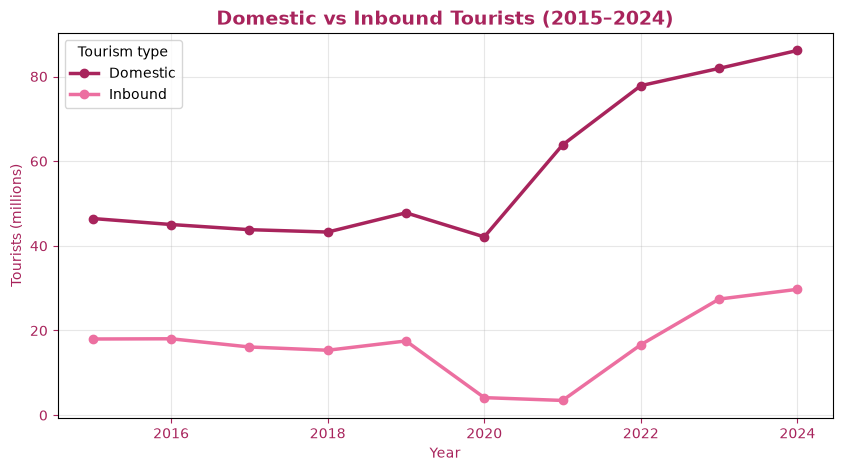

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

by_type.plot(
    ax=ax,
    color=["#A8245C", "#EC6FA0"],
    marker="o",
    linewidth=2.5,
)

ax.set_title("Domestic vs Inbound Tourists (2015–2024)", color="#A8245C", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", color="#A8245C")
ax.set_ylabel("Tourists (millions)", color="#A8245C")
ax.tick_params(colors="#A8245C")
ax.legend(title="Tourism type")
ax.grid(alpha=0.3)
plt.show()

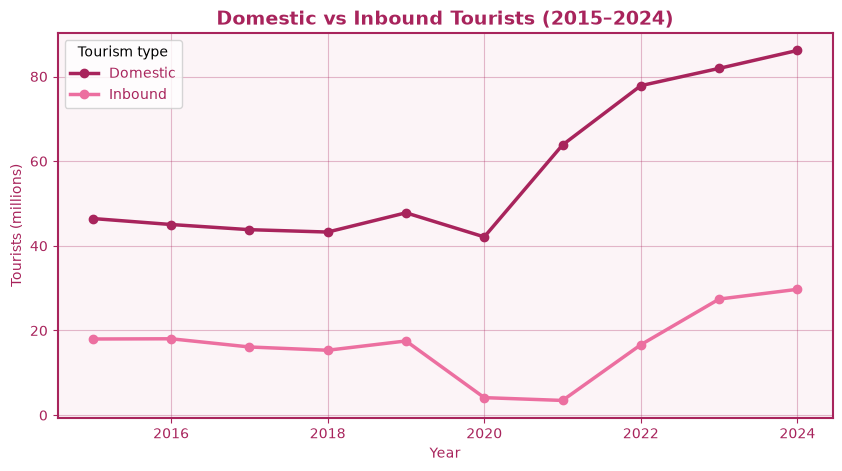

In [47]:
DARK_PINK = "#A8245C"
INSIDE = "#FCF4F7"

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor(INSIDE)

by_type.plot(
    ax=ax,
    color=[DARK_PINK, "#EC6FA0"],
    marker="o",
    linewidth=2.5,
)

ax.set_title("Domestic vs Inbound Tourists (2015–2024)", color=DARK_PINK, fontsize=14, fontweight="bold")
ax.set_xlabel("Year", color=DARK_PINK)
ax.set_ylabel("Tourists (millions)", color=DARK_PINK)
ax.tick_params(colors=DARK_PINK)

for side in ax.spines.values():
    side.set_color(DARK_PINK)
    side.set_linewidth(1.5)

ax.legend(title="Tourism type", labelcolor=DARK_PINK)
ax.grid(alpha=0.3, color=DARK_PINK)
plt.show()

### Domestic vs inbound tourism (2015–2024)

- **Domestic tourism is always much bigger** than inbound tourism, about **3 times larger** in 2024 (86.2 million vs 29.7 million).
- **COVID-19 hit inbound tourism hard:** it fell from **17.5 million in 2019** to just **3.5 million in 2021**, the lowest year, because borders were closed.
- **Domestic tourism did the opposite:** it **grew** to **63.8 million in 2021**, likely because people who couldn't travel abroad traveled inside Saudi Arabia instead.
- **Both recovered strongly after 2021.** By 2024, domestic tourism was **80% above** its 2019 level, and inbound tourism was **70% above** it.

In [48]:
stay = df_2024.groupby("region")[["overnight_stays_thousands", "tourists_thousands"]].sum()

stay["avg_stay_nights"] = stay["overnight_stays_thousands"] / stay["tourists_thousands"]

stay.sort_values("avg_stay_nights", ascending=False)

,overnight_stays_thousands,tourists_thousands,avg_stay_nights
region,,,
Hail,32652.0,2167.0,15.067836
Makkah,561411.0,43057.0,13.038786
Al-Qassim,50191.0,5189.0,9.672577
Najran,12403.0,1283.0,9.667186
Al-Jouf,14048.0,1490.0,9.428188
Al-Baha,10400.0,1135.0,9.162996
Aseer,64208.0,7492.0,8.570208
Tabuk,26043.0,3244.0,8.028052
Riyadh,148188.0,20458.0,7.243523


In [49]:
df_2024[df_2024["region"] == "Hail"][["tourism_type", "tourists_thousands", "avg_stay_nights"]]

,tourism_type,tourists_thousands,avg_stay_nights
109,Domestic,1841.0,7.5
119,Inbound,326.0,57.8


### Which regions have the longest stays? (2024)

- **Hail has the longest average stay: 15.1 nights**, followed by **Makkah (13.0 nights)**.
- Hail's high average comes from **inbound visitors, who stay about 57.8 nights**, compared with 7.5 nights for domestic tourists. These long stays may be people visiting friends and relatives, which official statistics also count as tourism.
- Makkah's long stays come from **inbound visitors (22 nights)**, mainly for Hajj and Umrah.
- **Eastern Province has the shortest stays (5.8 nights)**, along with Madinah and Jazan (5.9 nights), which suggests shorter trips such as weekend visits.

👉 An average can hide very different groups, so it's worth splitting it (here, by domestic and inbound) before drawing conclusions.

In [50]:
growth = df[df["year"].isin([2019, 2024])].pivot_table(
    index="region",
    columns="year",
    values="tourists_thousands",
    aggfunc="sum",
)

growth

year,2019,2024
region,,
Al-Baha,1465.0,1135.0
Al-Jouf,567.0,1490.0
Al-Qassim,1555.0,5189.0
Aseer,4967.0,7492.0
Eastern Province,7414.0,18642.0
Hail,988.0,2167.0
Jazan,2368.0,2949.0
Madinah,7299.0,7160.0
Makkah,27006.0,43057.0


In [51]:
growth["growth_pct"] = (growth[2024] - growth[2019]) / growth[2019] * 100

growth.sort_values("growth_pct", ascending=False)

year,2019,2024,growth_pct
region,,,
Al-Qassim,1555.0,5189.0,233.697749
Al-Jouf,567.0,1490.0,162.786596
Eastern Province,7414.0,18642.0,151.443216
Riyadh,8873.0,20458.0,130.564634
Northern Borders,707.0,1618.0,128.854314
Najran,571.0,1283.0,124.693520
Hail,988.0,2167.0,119.331984
Tabuk,1553.0,3244.0,108.886027
Makkah,27006.0,43057.0,59.434940


In [53]:
growth["growth_pct"] = growth["growth_pct"].round(1)

growth.sort_values("growth_pct", ascending=False)

year,2019,2024,growth_pct
region,,,
Al-Qassim,1555.0,5189.0,233.7
Al-Jouf,567.0,1490.0,162.8
Eastern Province,7414.0,18642.0,151.4
Riyadh,8873.0,20458.0,130.6
Northern Borders,707.0,1618.0,128.9
Najran,571.0,1283.0,124.7
Hail,988.0,2167.0,119.3
Tabuk,1553.0,3244.0,108.9
Makkah,27006.0,43057.0,59.4


In [54]:
growth.sort_values("growth_pct", ascending=False).style.format({"growth_pct": "{:.1f}%"})

year,2019,2024,growth_pct
region,,,
Al-Qassim,1555.000000,5189.000000,233.7%
Al-Jouf,567.000000,1490.000000,162.8%
Eastern Province,7414.000000,18642.000000,151.4%
Riyadh,8873.000000,20458.000000,130.6%
Northern Borders,707.000000,1618.000000,128.9%
Najran,571.000000,1283.000000,124.7%
Hail,988.000000,2167.000000,119.3%
Tabuk,1553.000000,3244.000000,108.9%
Makkah,27006.000000,43057.000000,59.4%


In [55]:
growth["increase_thousands"] = growth[2024] - growth[2019]

growth.sort_values("increase_thousands", ascending=False)

year,2019,2024,growth_pct,increase_thousands
region,,,,
Makkah,27006.0,43057.0,59.4,16051.0
Riyadh,8873.0,20458.0,130.6,11585.0
Eastern Province,7414.0,18642.0,151.4,11228.0
Al-Qassim,1555.0,5189.0,233.7,3634.0
Aseer,4967.0,7492.0,50.8,2525.0
Tabuk,1553.0,3244.0,108.9,1691.0
Hail,988.0,2167.0,119.3,1179.0
Al-Jouf,567.0,1490.0,162.8,923.0
Northern Borders,707.0,1618.0,128.9,911.0


### Which regions grew the fastest? (2019 vs 2024)

- **Al-Qassim grew the fastest (+234%)**, more than tripling its tourists, followed by **Al-Jouf (+163%)** and **Eastern Province (+151%)**.
- **Makkah grew by only 59%**, but it added **16.1 million tourists**, the **largest increase of any region**. Its percentage looks small because it started from a much bigger base.
- **Two regions declined:** **Al-Baha (−22.5%)** and **Madinah (−1.9%)**.

Note: Percentage growth and absolute growth tell different stories, so it's best to look at both.

## 📌 Summary: Key findings

1. **Tourism nearly doubled after COVID-19.** Saudi Arabia had **115.9 million tourists in 2024**, up from **65.3 million in 2019**. The lowest year was **2020 (46.2 million)**.

2. **Domestic tourism is the backbone.** Domestic tourists were about **3 times** more than inbound tourists in 2024 (**86.2M vs 29.7M**). During COVID-19, inbound tourism fell to **3.5 million (2021)**, while domestic tourism actually grew.

3. **Tourism is concentrated in a few regions.** Makkah, Riyadh, and Eastern Province received about **71% of all tourists** in 2024. **Makkah alone** received **37% of tourists** and **60% of tourism spending**, mostly from inbound visitors (Hajj and Umrah).

4. **More tourists doesn't always mean more spending.** Where tourists come from and how long they stay make a big difference. Madinah ranks higher in spending than in tourist numbers, while Jazan ranks lower.

5. **Fast growth in smaller regions.** From 2019 to 2024, **Al-Qassim grew the fastest (+234%)**, while **Makkah added the most tourists (+16.1M)**. **Al-Baha (−22.5%)** and **Madinah (−1.9%)** declined.

6. **Averages can hide different groups.** Hail has the longest average stay (**15.1 nights**), driven by inbound visitors who stay about **58 nights**.

**Data note:** official statistics from the Saudi Tourism Authority (2015–2024). One row of fake zeros (Al-Baha, 2017, inbound) was treated as missing data.